In [34]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unityandnormal as unn
import seaborn as sns

def plot_value_on_map(df, value_col, title=None):
    fig = px.scatter_map(
        df,
        lat='latitude',
        lon='longitude',
        color=value_col,
        color_continuous_scale='RdBu_r',  # good for diverging values like yours (-1 to 1 range)
        size_max=8,
        zoom=6,
        map_style='open-street-map',
        hover_name=df.index,  # shows station number on hover
        title=title or f"{value_col} by station"
    )
    fig.update_traces(marker=dict(size=10))
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()


In [52]:
df = pd.read_pickle("Data/GaugeCorrs.pkl")

df["A"] = np.sqrt(df["A"])
df["H"] = np.where(df["H"]<0, np.nan, df["H"])

# for col in df.columns[:5]:
#     df[col] = df[col]**2
print(df)

                0         P         T         M         R   latitude  \
6235300  0.145351  0.818424  0.487639 -0.324836 -0.021328  47.463333   
6235200  0.140270  0.767814  0.782636 -0.323425 -0.163218  47.257500   
6335451  0.625788  0.705217  0.341739 -0.281225  0.226087  47.672900   
6935411  0.601691  0.727253  0.523026 -0.144321 -0.310345  47.484600   
6935403  0.491444  0.798246  0.722807 -0.140598 -0.070175  47.358000   
...           ...       ...       ...       ...       ...        ...   
6935019  0.046927  0.747840  0.702983  0.576304 -0.269018  46.745740   
6335620  0.401872  0.321364 -0.361145  0.585314  0.026037  49.345874   
6935541 -0.019984  0.701048  0.615255  0.625668 -0.312755  46.858000   
6335540  0.292603  0.357099 -0.176132  0.642973  0.248922  50.181522   
6935530  0.124887  0.698261  0.809918  0.741107 -0.296148  46.631300   

         longitude          A         H  
6235300   9.681944  14.054537   394.530  
6235200   9.729200   5.768015   830.980  
6335451  

In [66]:
# Plot each value column
for col in ['T' ,'M', 'P']:
    plot_value_on_map(df, col)

In [63]:
import scipy.stats as stats

def spearmanr_pval(x,y):
    return stats.spearmanr(x,y).pvalue

def matrixplot(data, figname):
    merged_data_i = pd.DataFrame(data.reset_index())
    # merged_data_i = merged_data_i.drop(columns=["time"])

    temp_expl_corr = np.array(merged_data_i.corr(method='spearman'))

    temp_expl_pval = np.array(merged_data_i.corr(method=spearmanr_pval))

    unn.corrmatrixplot(merged_data_i.columns, temp_expl_corr, temp_expl_pval)
    # plt.savefig(figname, dpi=300)
    return temp_expl_corr

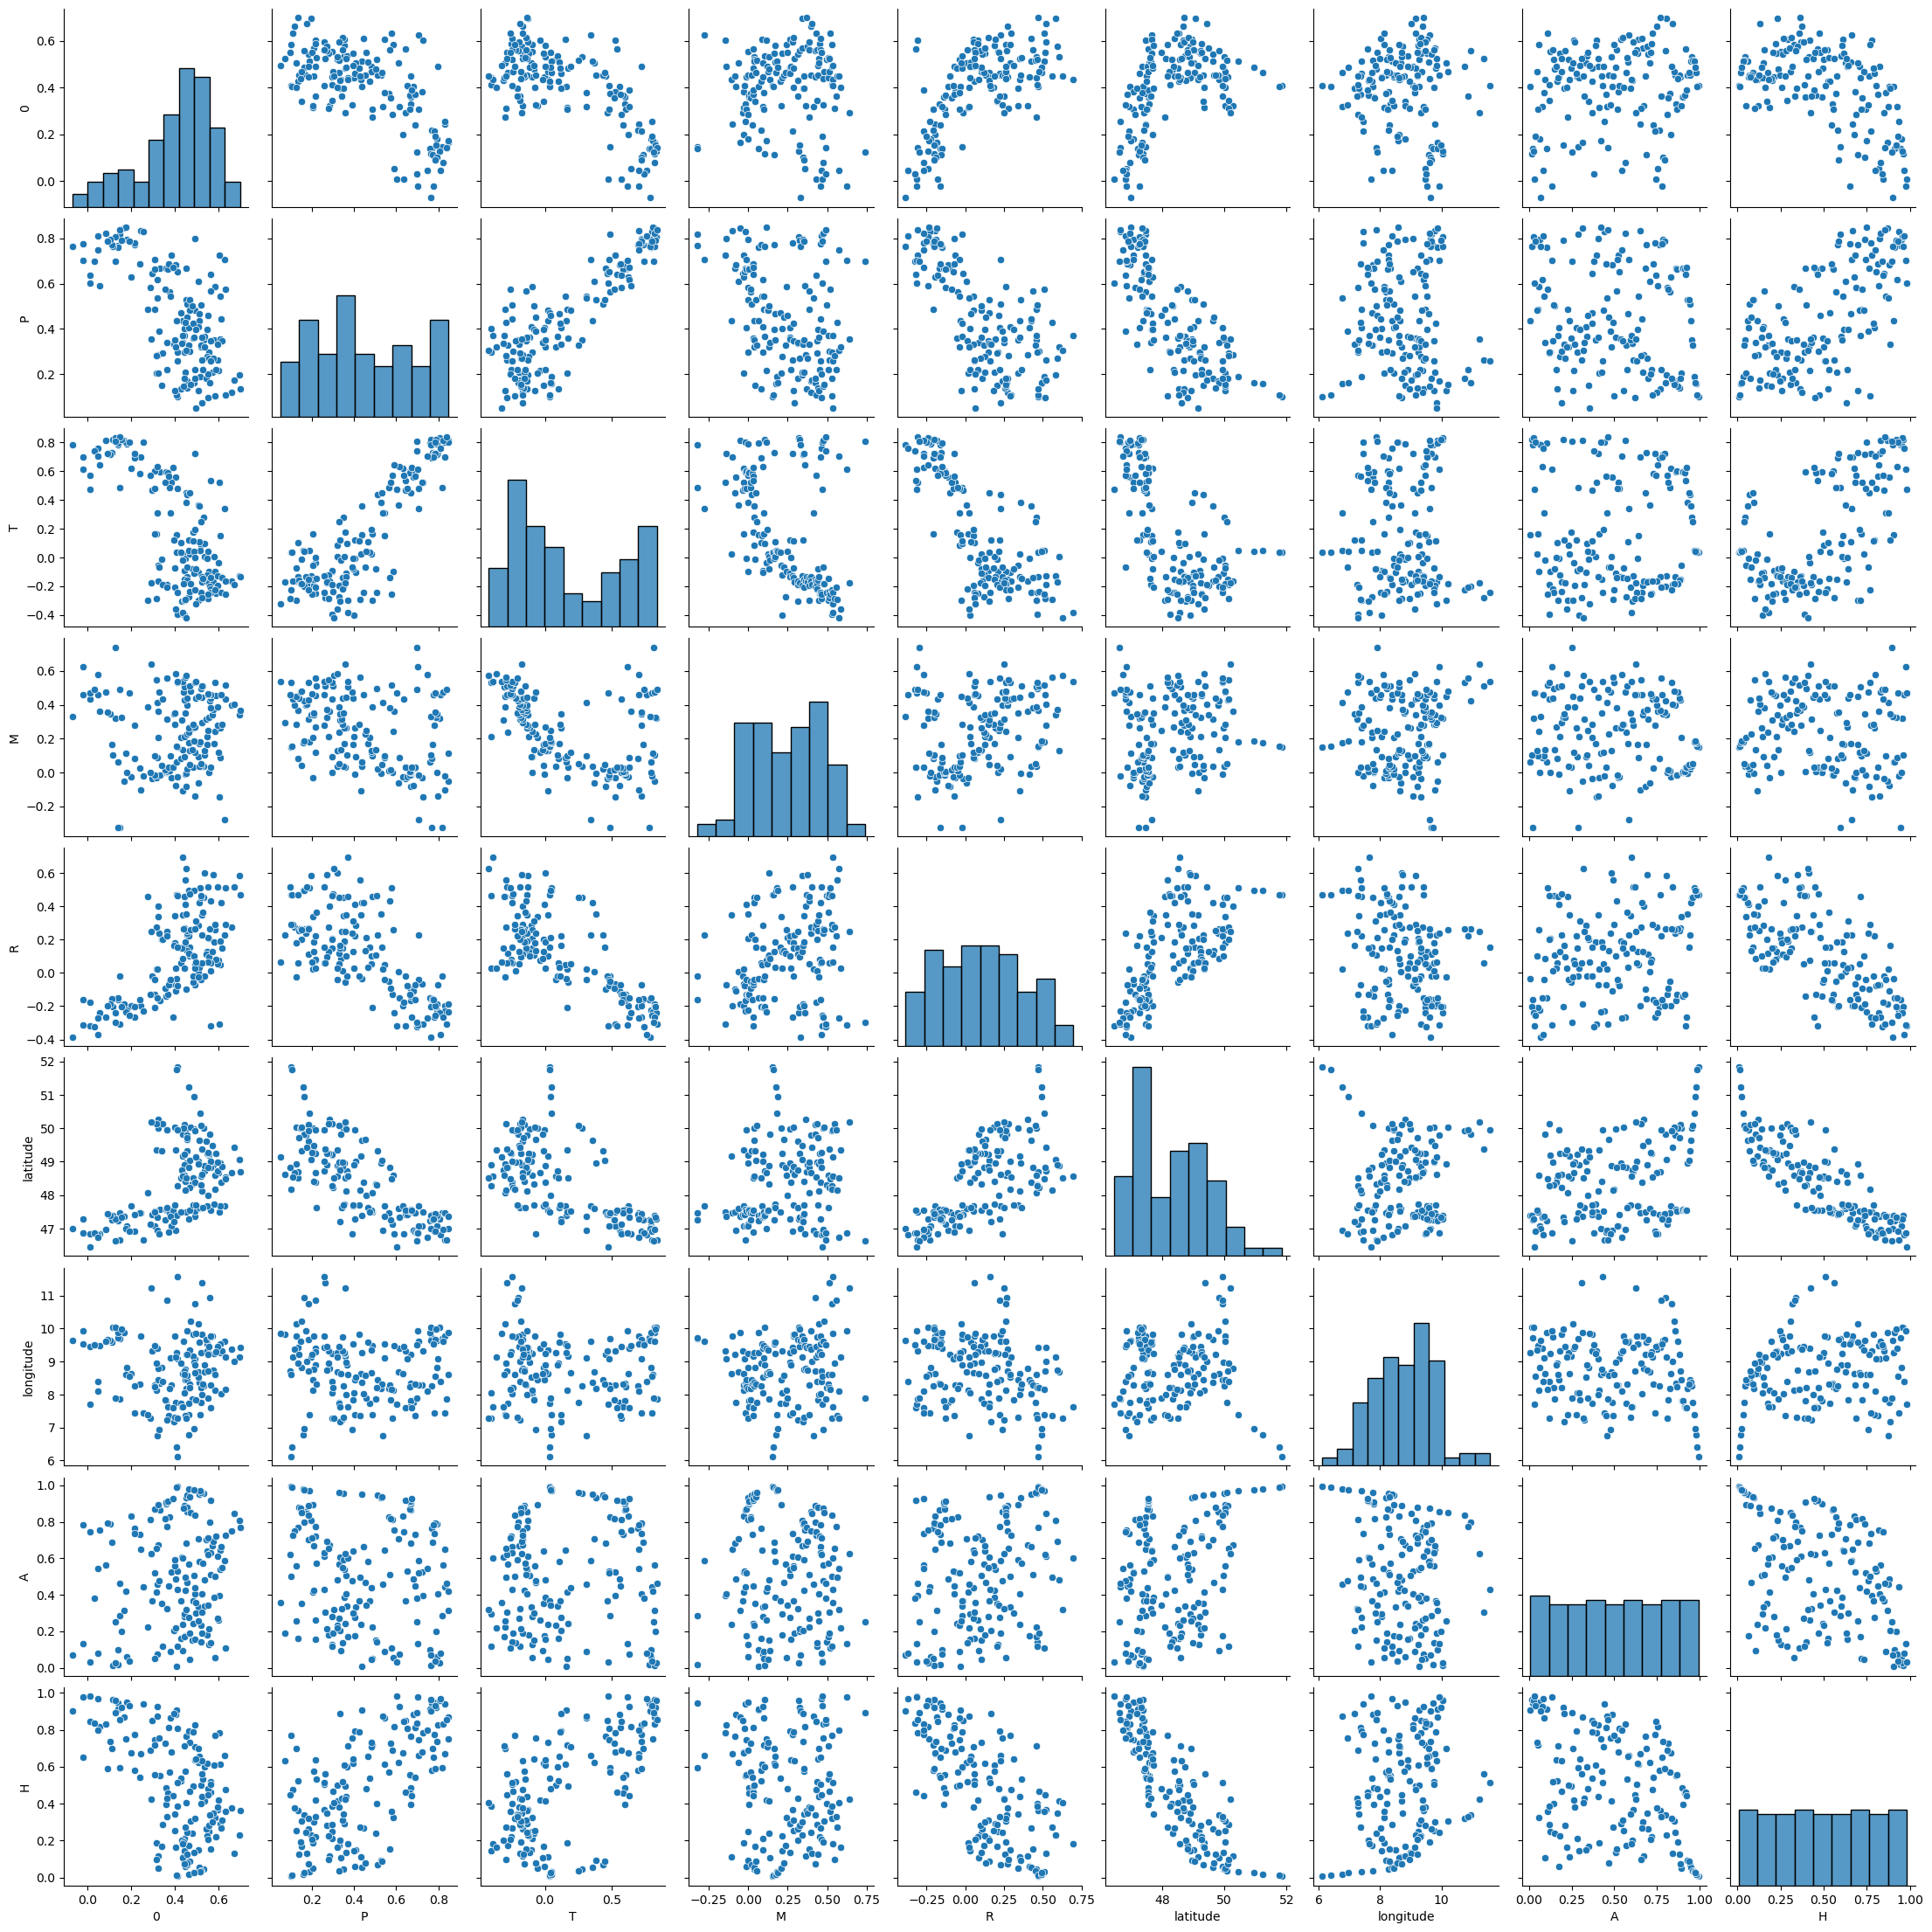

In [65]:
df_u = df #unn.unity(df)
df_u["A"] = unn.unity(df_u["A"])
df_u["H"] = unn.unity(df_u["H"])
# df_u = unn.sd_normal(df_u)
# matrixplot(df_u, "corr on corr")
sns.pairplot(df_u, vars=df_u.columns)
# unn.corrmatrixplot()